# Business Understanding

## Project Domain

Domain: Kecerdasan Buatan (Artificial Intelligence) & Pemrosesan Bahasa Alami (Natural Language Processing / NLP)
Sub-Domain: Deteksi Sarkasme dalam Teks & Aplikasi Berbasis Machine Learning

Proyek ini berada dalam domain kecerdasan buatan (AI), khususnya dalam pemrosesan bahasa alami (Natural Language Processing / NLP), yang berfokus pada analisis dan pemahaman teks manusia. Dalam sub-domain ini, tujuan utama adalah deteksi sarkasme dalam kalimat atau teks menggunakan teknik-teknik pembelajaran mesin (machine learning) dan pembelajaran mendalam (deep learning).

Pemrosesan Bahasa Alami (NLP) adalah cabang dari kecerdasan buatan yang bertujuan untuk mengembangkan sistem yang dapat memahami, memproses, dan menghasilkan teks atau ucapan manusia dengan cara yang berarti. Salah satu tantangan utama dalam NLP adalah menangani sarkasme, yang sering kali menciptakan ketidaksesuaian antara kata-kata yang digunakan dalam kalimat dan makna yang sebenarnya dimaksudkan oleh pembicara.

Deteksi Sarkasme merupakan sub-domaine NLP yang fokus pada pengenalan pola dalam teks yang mengindikasikan penggunaan sarkasme. Dalam konteks ini, sistem yang dibangun berusaha untuk mengidentifikasi apakah sebuah kalimat mengandung sarkasme atau tidak berdasarkan model pembelajaran mendalam yang dilatih menggunakan dataset teks yang sudah dilabeli.

Sarkasme sering kali sulit dipahami oleh model komputasi karena adanya ambiguitas antara makna literal dari kata-kata dan makna yang sebenarnya dimaksud. Oleh karena itu, proyek ini memanfaatkan model deep learning, seperti Transformer, untuk mengidentifikasi pola dan konteks dalam kalimat yang mengindikasikan adanya sarkasme. Proyek ini juga memanfaatkan tokenisasi dan embedding untuk merepresentasikan kata dan urutan kata dalam kalimat secara lebih efektif.

Dalam hal ini, proyek ini sangat relevan dengan perkembangan terkini dalam NLP yang berfokus pada kemampuan mesin untuk memahami konteks dan nuansa dalam bahasa manusia, khususnya dalam menghadapi tantangan seperti sarkasme yang tidak selalu dapat dipahami secara langsung hanya dengan menganalisis kata-kata yang ada dalam kalimat.

## Problem Statements

Sarkasme adalah bentuk komunikasi yang sering digunakan dalam bahasa sehari-hari, baik dalam percakapan langsung maupun dalam bentuk tulisan. Namun, deteksi sarkasme dalam teks menjadi sangat sulit karena adanya ketidaksesuaian antara kata-kata yang digunakan dan makna yang ingin disampaikan. Di sisi lain, model pemrosesan bahasa alami tradisional lebih mudah menganalisis teks literal, di mana makna kata-kata dapat lebih langsung dipahami.

Masalah utama dalam proyek ini adalah:

1. Bagaimana cara mendeteksi sarkasme dalam kalimat yang terdiri dari kata-kata yang tidak secara eksplisit menunjukkan ironi atau kebalikan dari makna sebenarnya?

2. Bagaimana cara mengembangkan model yang bisa membedakan antara kalimat yang sarkastik dan yang tidak, hanya berdasarkan pada pola-pola dalam teks?

## Goals

Tujuan dari proyek ini adalah:

1. Membangun model pembelajaran mendalam yang dapat mendeteksi apakah sebuah kalimat mengandung sarkasme atau tidak.

2. Menggunakan dataset nyata, dalam hal ini dataset berita dari Kaggle yang mengandung headline berita yang berpotensi mengandung sarkasme.

3. Menerapkan arsitektur Transformer dan Embedding untuk mendapatkan representasi kata dan posisi yang lebih baik dalam kalimat.

4. Mengembangkan aplikasi berbasis Streamlit yang memungkinkan pengguna untuk menguji apakah kalimat yang dimasukkan adalah sarkastik atau tidak, dengan antarmuka yang mudah digunakan.

5. eningkatkan akurasi model dalam mendeteksi sarkasme pada teks dalam bahasa Inggris.

## Solution Statements

Solusi yang diajukan dalam proyek ini adalah:

1. Penggunaan Arsitektur Transformer: Arsitektur Transformer, khususnya menggunakan lapisan seperti Multi-Head Attention dan Token-and-Position Embedding, dapat memproses hubungan antar kata dalam sebuah kalimat lebih efektif. Hal ini memungkinkan model untuk memahami konteks dan pola dalam kalimat yang sering kali diperlukan untuk mendeteksi sarkasme.

2. Dataset Berita Sarcastic: Dataset yang digunakan dalam proyek ini diambil dari Kaggle, yang berisi berita-berita dengan label sarkasme atau tidak. Data ini sudah dilabeli sebelumnya, sehingga dapat digunakan untuk melatih model untuk mengenali pola-pola sarkasme dalam teks.

3. Preprocessing Teks: Sebelum dimasukkan ke dalam model, teks diproses dengan tokenisasi, diubah menjadi representasi numerik dengan menggunakan tokenizer yang sudah dilatih. Kemudian, urutan kata yang dihasilkan diproses untuk memiliki panjang yang konsisten menggunakan padding, sehingga dapat diproses oleh model.

4. Pengembangan Aplikasi Web Interaktif: Dengan menggunakan Streamlit, aplikasi ini memungkinkan pengguna untuk memasukkan teks secara interaktif dan menerima prediksi apakah teks tersebut mengandung sarkasme atau tidak. Pengguna dapat langsung melihat hasil prediksi dalam bentuk yang mudah dipahami.

5. Model Deep Learning: Model yang digunakan adalah model berbasis deep learning dengan arsitektur Transformer yang telah dilatih menggunakan dataset berita dari Kaggle. Hasil akhir dari model ini adalah sebuah sistem prediksi yang dapat mengklasifikasikan teks sebagai "Sarkastik" atau "Tidak Sarkastik".

In [57]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt 
import seaborn as sns 
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pickle

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding, Layer, Dense, Dropout, MultiHeadAttention, LayerNormalization, Input, GlobalAveragePooling1D
from tensorflow.keras.layers import LSTM, Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix

In [5]:
nltk.download('stopwords')
lemm = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Data Understanding

In [7]:
data1 = pd.read_json('../input/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset_v2.json', lines=True)
data2 = pd.read_json('../input/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json', lines=True)

data1 = data1[['headline','is_sarcastic']]
data2 = data2[['headline','is_sarcastic']]

data = pd.concat([data1,data2])
data.reset_index(drop=True, inplace=True)

In [10]:
data.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


## Exploratory Data Analysis

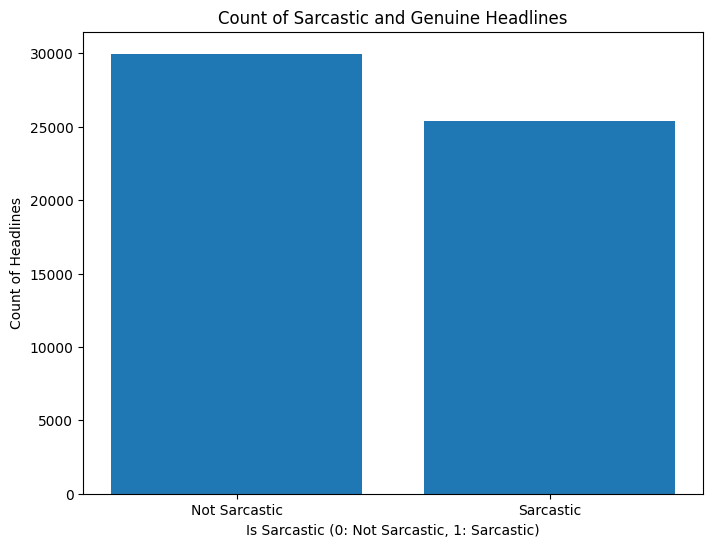

In [11]:
data_grouped = data.groupby('is_sarcastic').count().reset_index()

# Create a bar chart using matplotlib
plt.figure(figsize=(8, 6))
plt.bar(data_grouped['is_sarcastic'], data_grouped['headline'])
plt.title('Count of Sarcastic and Genuine Headlines')
plt.xlabel('Is Sarcastic (0: Not Sarcastic, 1: Sarcastic)')
plt.ylabel('Count of Headlines')
plt.xticks(ticks=[0, 1], labels=['Not Sarcastic', 'Sarcastic'])
plt.show()

In [12]:
stop_words = stopwords.words('english')
stop_words.remove('not')

def text_cleaning(x):
    
    headline = re.sub('\s+\n+', ' ', x)
    headline = re.sub('[^a-zA-Z0-9]', ' ', x)
    headline = headline.lower()
    headline = headline.split()
    
    headline = [lemm.lemmatize(word, "v") for word in headline if not word in stop_words]
    headline = ' '.join(headline)
    
    return headline

In [13]:
data['clean_headline'] = data['headline'].apply(text_cleaning)

In [14]:
data['sentence_length'] = data['clean_headline'].apply(lambda x: len(x.split()))

In [15]:
data.head()

,headline,is_sarcastic,clean_headline,sentence_length
0,thirtysomething scientists unveil doomsday clo...,1,thirtysomething scientists unveil doomsday clo...,7
1,dem rep. totally nails why congress is falling...,0,dem rep totally nail congress fall short gende...,10
2,eat your veggies: 9 deliciously different recipes,0,eat veggies 9 deliciously different recipes,6
3,inclement weather prevents liar from getting t...,1,inclement weather prevent liar get work,6
4,mother comes pretty close to using word 'strea...,1,mother come pretty close use word stream corre...,8


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

Text(0, 0.5, 'Frequency')

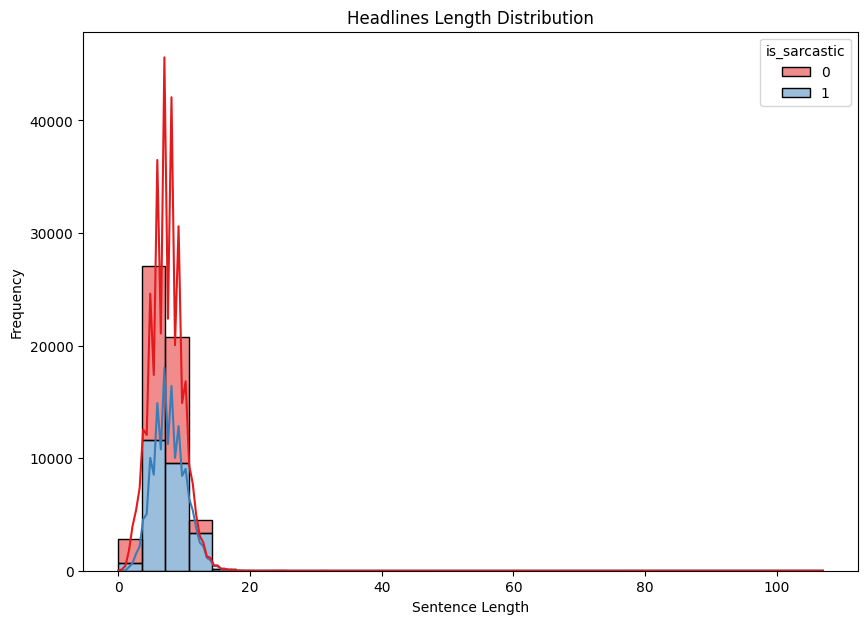

In [16]:
plt.figure(figsize=(10, 7))
sns.histplot(data=data, x="sentence_length", hue="is_sarcastic", kde=True, bins=30, multiple="stack", palette="Set1")
plt.title("Headlines Length Distribution")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")

In [20]:
data[data['sentence_length']>=100]['headline']

7302    hot wheels ranked number one toy for rolling d...
Name: headline, dtype: object

In [21]:
data.drop(data[data['sentence_length'] >= 100].index, inplace = True)
data.reset_index(inplace=True, drop=True)

In [23]:
data.head()

,headline,is_sarcastic,clean_headline,sentence_length
0,thirtysomething scientists unveil doomsday clo...,1,thirtysomething scientists unveil doomsday clo...,7
1,dem rep. totally nails why congress is falling...,0,dem rep totally nail congress fall short gende...,10
2,eat your veggies: 9 deliciously different recipes,0,eat veggies 9 deliciously different recipes,6
3,inclement weather prevents liar from getting t...,1,inclement weather prevent liar get work,6
4,mother comes pretty close to using word 'strea...,1,mother come pretty close use word stream corre...,8


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

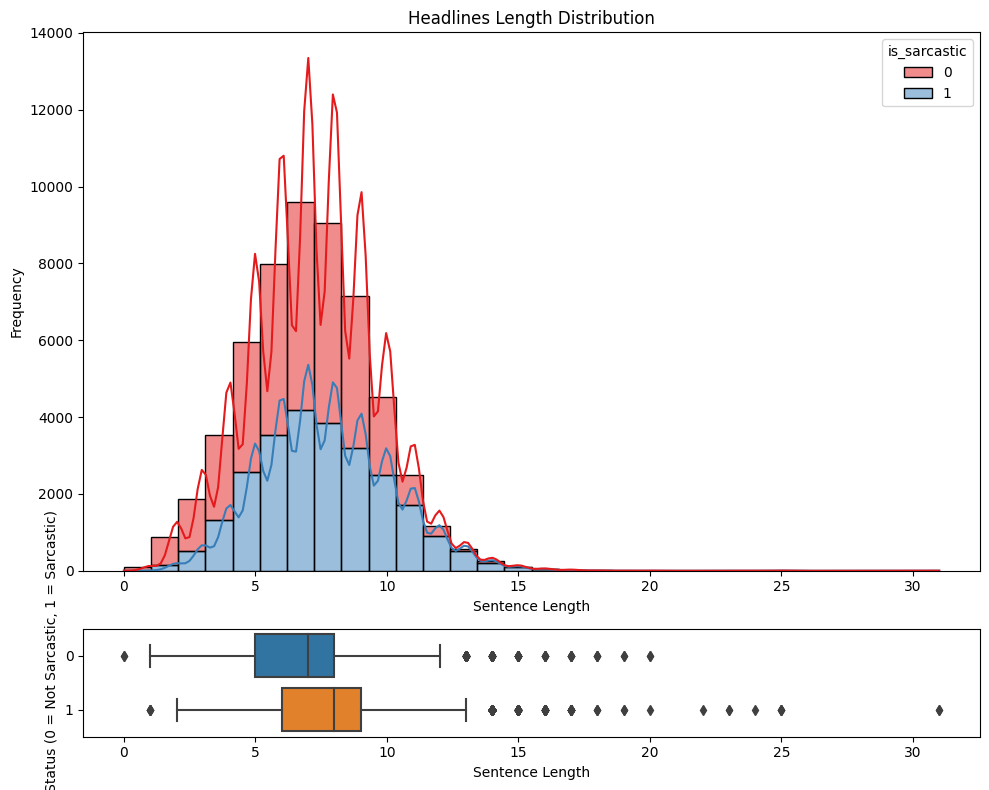

In [24]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [5, 1]})

sns.histplot(data=data, x="sentence_length", hue="is_sarcastic", kde=True, bins=30, multiple="stack", palette="Set1", ax=ax[0])
ax[0].set_title("Headlines Length Distribution")
ax[0].set_xlabel("Sentence Length")
ax[0].set_ylabel("Frequency")

sns.boxplot(x="sentence_length", y="is_sarcastic", data=data, orient="h", ax=ax[1])
ax[1].set_xlabel("Sentence Length")
ax[1].set_ylabel("Sarcasm Status (0 = Not Sarcastic, 1 = Sarcastic)")

plt.tight_layout()
plt.show()

In [25]:
sarcastic = data[data['is_sarcastic']==1]['clean_headline'].tolist()
genuine = data[data['is_sarcastic']==0]['clean_headline'].tolist()

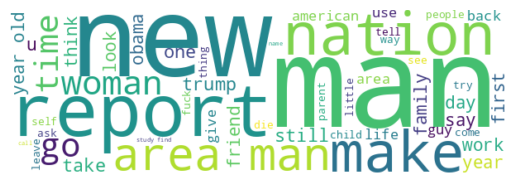

In [26]:
wordcloud = WordCloud(max_words=50, width=600, background_color='white').generate(" ".join(sarcastic))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

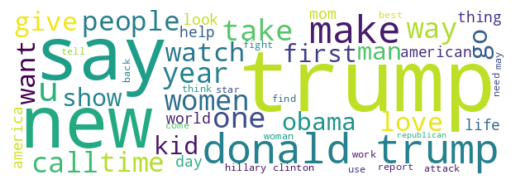

In [27]:
wordcloud = WordCloud(max_words=50, width=600, background_color='white').generate(" ".join(genuine))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Data Preparation

In [31]:
sentences = data['clean_headline']
label = data['is_sarcastic']

In [33]:
X_train, X_val, y_train, y_val = train_test_split(
    sentences, label, test_size=0.2, stratify=label, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    
    X_val, y_val, test_size=0.5, stratify=y_val, random_state=42
)

In [34]:
max_len = 20           
oov_token = '00_V'   
padding_type = 'post'   
trunc_type = 'post'     

In [35]:
tokenizer = Tokenizer(oov_token=oov_token)
tokenizer.fit_on_texts(X_train)

In [36]:
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocab Size: {vocab_size}")

Vocab Size: 20943


In [37]:
def preprocess_data(text_data):
    sequences = tokenizer.texts_to_sequences(text_data)
    return pad_sequences(sequences, maxlen=max_len, padding=padding_type, truncating=trunc_type)

X_train = preprocess_data(X_train)
X_val = preprocess_data(X_val)
X_test = preprocess_data(X_test)

# Model Training

In [40]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, heads, neurons):
        super(TransformerEncoder, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=heads, key_dim=embed_dim)
        self.ffn = Sequential(
            [layers.Dense(neurons, activation="relu"), layers.Dense(embed_dim),]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(0.5)
        self.dropout2 = layers.Dropout(0.5)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)
    
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [41]:
embed_dim = 50  
heads = 2  
neurons = 32
maxlen = 20

inputs = layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
x = embedding_layer(inputs)
transformer_block = TransformerEncoder(embed_dim, heads, neurons)
x = transformer_block(x)
x = layers.GlobalAveragePooling1D()(x)
x = Dropout(0.35)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = Model(inputs=inputs, outputs=outputs)

In [42]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.0003), loss='binary_crossentropy', metrics=['accuracy'])


In [43]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ token_and_position_embedding_1       │ (None, 20, 50)              │       1,048,150 │
│ (TokenAndPositionEmbedding)          │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_encoder_1                │ (None, 20, 50)              │          23,832 │
│ (TransformerEncoder)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 50)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,072,033 (4.09 MB)

 Trainable params: 1,072,033 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
earlystopping = EarlyStopping(monitor='val_loss',min_delta = 0.001, patience = 1, verbose = 1)

In [47]:
history = model.fit(X_train,y_train,
                    validation_data=(X_val,y_val),
                    epochs=25,
                    batch_size=32,
                    callbacks=[earlystopping])

Epoch 1/25
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.6759 - loss: 0.5792 - val_accuracy: 0.8614 - val_loss: 0.3236
Epoch 2/25
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9051 - loss: 0.2444 - val_accuracy: 0.8937 - val_loss: 0.2913
Epoch 3/25
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9475 - loss: 0.1453 - val_accuracy: 0.9179 - val_loss: 0.2488
Epoch 4/25
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9693 - loss: 0.0901 - val_accuracy: 0.9295 - val_loss: 0.2606
Epoch 4: early stopping


# Model Evalution

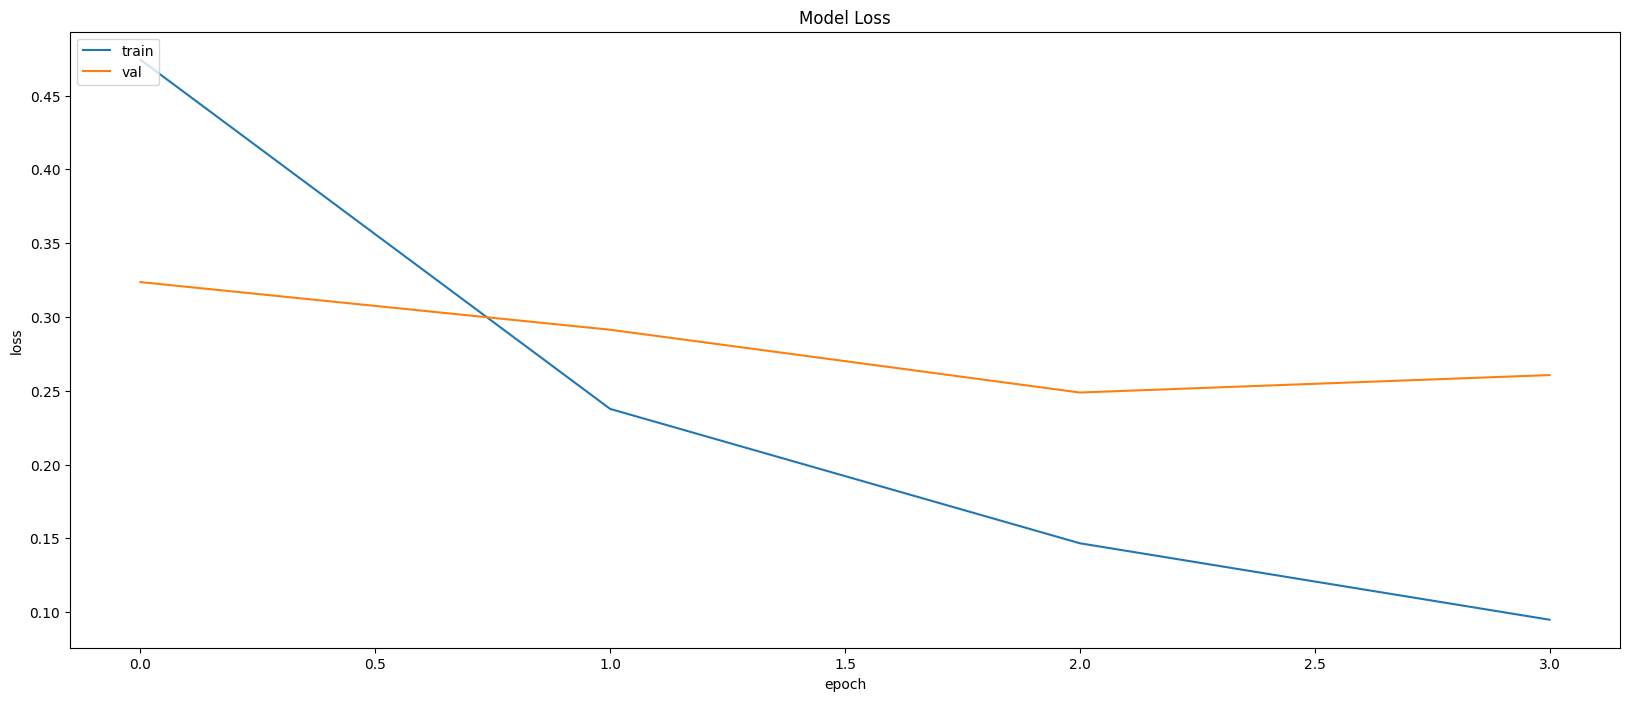

In [48]:
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


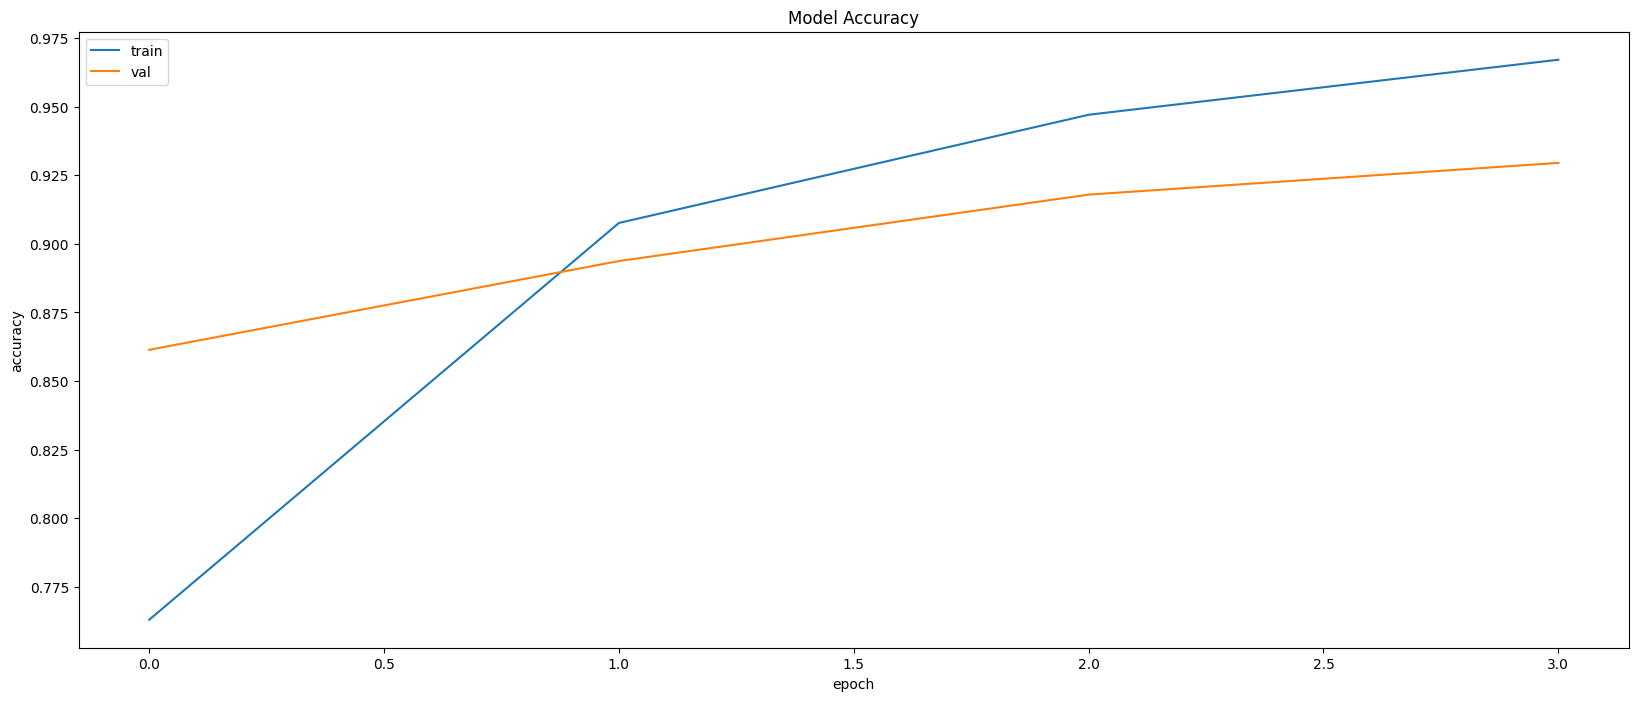

In [49]:
plt.figure(figsize=(20,8))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [50]:
loss, acc = model.evaluate(X_test,y_test)

173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9349 - loss: 0.2272


In [51]:
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")

Loss: 0.2352
Accuracy: 0.9344


In [54]:
y_pred = model.predict(X_val)

y_pred = (y_pred > 0.5).astype(int)

report = classification_report(y_val, y_pred)
print("Classification Report:")
print(report)

173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      2997
           1       0.93      0.92      0.92      2536

    accuracy                           0.93      5533
   macro avg       0.93      0.93      0.93      5533
weighted avg       0.93      0.93      0.93      5533



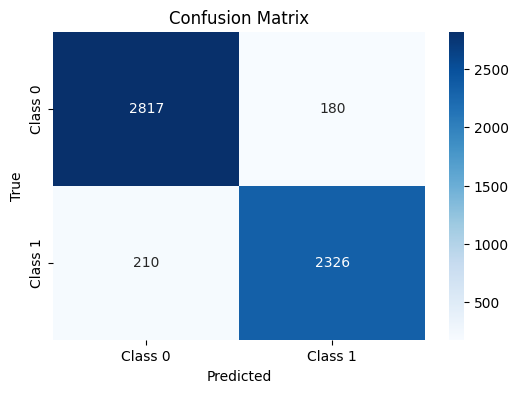

In [55]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Deployment

## Save Model

In [56]:
model.save('sarcasm_detector_model.h5')

In [58]:
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

## Model Simulation

In [69]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super(TokenAndPositionEmbedding, self).__init__(**kwargs)
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, heads, neurons, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [layers.Dense(neurons, activation="relu"), layers.Dense(embed_dim)]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(0.5)
        self.dropout2 = layers.Dropout(0.5)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)



In [70]:
custom_objects = {
    'TokenAndPositionEmbedding': TokenAndPositionEmbedding,
    'TransformerEncoder': TransformerEncoder
}

In [71]:
loaded_model = tf.keras.models.load_model('sarcasm_detector_model.h5', custom_objects=custom_objects)

with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

In [72]:
def preprocess_input(sentence, maxlen=20):
    sequences = tokenizer.texts_to_sequences([sentence])
    padded_sequences = pad_sequences(sequences, maxlen=maxlen)
    return padded_sequences

def predict_sarcasm(sentence):
    processed_input = preprocess_input(sentence)

    prediction = loaded_model.predict(processed_input)
    if prediction > 0.5:
        return "Sarcastic"
    else:
        return "Not Sarcastic"


In [76]:
# Contoh kalimat uji
test_sentence = "Oh, great! Another rainy day!"  # Kalimat sarkastik
result = predict_sarcasm(test_sentence)
print(f"Kalimat: {test_sentence} => {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Kalimat: Oh, great! Another rainy day! => Not Sarcastic


In [77]:
# Contoh kalimat uji
test_sentence = "Sure, because waiting in line for two hours is my favorite hobby"  # Kalimat sarkastik
result = predict_sarcasm(test_sentence)
print(f"Kalimat: {test_sentence} => {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Kalimat: Sure, because waiting in line for two hours is my favorite hobby => Sarcastic
